This notebook was authored by **Emma Willems** and **Carl-Erik Heyvaert** under the close supervision of **Prof. Dr. Kristof Stouthuysen**. All authors and supervisors are members of the [Centre for Financial Leadership & Digital Transformation](https://www.vlerick.com/en/for-companies/research-for-your-company/centre-for-financial-leadership-and-digital-transformation/) at **Vlerick Business School**.

📧 **Contact Information:**  
- 📩 [carlerik.heyvaert@vlerick.com](mailto:carlerik.heyvaert@vlerick.com)  
- 📩 [kristof.stouthuysen@vlerick.com](mailto:kristof.stouthuysen@vlerick.com)

## Recap Supervised ML

#### Import Packages

In [ ]:
# data preprocessing
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# machine learning modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, classification_report,\
recall_score, precision_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import shap

# unsupervised machine learning
!pip install kmodes kneed
from kmodes.kmodes import KModes
from kneed import KneeLocator

import warnings
warnings.filterwarnings('ignore')

#### Load Data

In [ ]:
%%capture
!wget -O hospital_dataset.csv 'https://drive.google.com/uc?export=download&id=1myndwZNmn1tLoXSomi54ZgzW4ftrGY5r'

df = pd.read_csv('hospital_dataset.csv')

#### Split Data

In [ ]:
df_survey = df.drop("Satisfaction", axis = 1)
# Save the target variable
df_satisfaction = df["Satisfaction"]
df_survey.head()

,CE_ACCESSIBILITY,CE_VALUEFORMONEY,EM_IMMEDIATEATTENTION,EM_NURSING,EM_DOCTOR,EM_OVERALL,AD_TIME,AD_TARRIFFPACKAGESEXPLAINATION,AD_STAFFATTITUDE,INR_ROOMCLEANLINESS,...,NS_CALLBELLRESPONSE,NS_NURSESATTITUDE,NS_NURSEPROACTIVENESS,NS_NURSEPATIENCE,OVS_OVERALLSTAFFATTITUDE,OVS_OVERALLSTAFFPROMPTNESS,OVS_SECURITYATTITUDE,DP_DISCHARGETIME,DP_DISCHARGEQUERIES,DP_DISCHARGEPROCESS
0,3,2,3,3,3,3,4,4,4,2,...,3,3,3,3,3,3,3,3,3,3
1,3,4,3,3,4,3,1,1,2,3,...,1,4,3,3,3,3,3,3,3,1
2,3,3,3,3,3,3,3,2,2,2,...,2,3,3,3,3,3,3,3,3,3
3,4,2,3,4,3,3,1,2,1,4,...,2,4,3,4,3,3,3,1,2,2
4,3,3,4,4,4,4,3,3,3,3,...,3,3,3,3,3,3,2,3,3,3


In [ ]:
df_satisfaction.head()

,Satisfaction
0,0
1,1
2,1
3,1
4,0


#### Define Train and Test Set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_survey, df_satisfaction, test_size=0.2, random_state=42) # Don't forget that stratify can be a powerful parameter when your dataset is heavily imbalanced

#### Fit Decision Tree - Exercise 2

In [ ]:
# Create a decision tree classifier
dt_model = DecisionTreeClassifier(random_state = 42)
# Fit the classifier on the training data
dt_model = dt_model.fit(X_train,y_train)
y_pred = dt_model.predict(X_test)


# Evaluate the performance
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.91      0.88       610
           1       0.94      0.91      0.92       959

    accuracy                           0.91      1569
   macro avg       0.90      0.91      0.90      1569
weighted avg       0.91      0.91      0.91      1569



#### Fit Random Forest Classifier

In [ ]:
# Create a Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)
# Fit the classifier on the training data
rf_model.fit(X_train, y_train)
# Make predictions on the test set
y_pred= rf_model.predict(X_test)


# Evaluate the performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       610
           1       0.95      0.94      0.94       959

    accuracy                           0.93      1569
   macro avg       0.93      0.93      0.93      1569
weighted avg       0.93      0.93      0.93      1569



#### SHAP Values - Exercise 1

In [ ]:
import shap
# Apply SHAP on the model
explainer = shap.Explainer(rf_model)
shap_values = explainer.shap_values(X_test) # In practice, you might start with X_train for a broad view of feature importance and then move on to X_test to verify that these insights hold up on unseen data.
shap_values # Each SHAP value represents how much each feature contributes to the output of the observation/row's prediction

array([[[-0.0385475 ,  0.0385475 ],
        [-0.07445769,  0.07445769],
        [-0.00131518,  0.00131518],
        ...,
        [-0.02112325,  0.02112325],
        [-0.03692267,  0.03692267],
        [-0.02344681,  0.02344681]],

       [[ 0.04711857, -0.04711857],
        [ 0.17160156, -0.17160156],
        [-0.01705684,  0.01705684],
        ...,
        [ 0.01014782, -0.01014782],
        [ 0.05127417, -0.05127417],
        [ 0.02729256, -0.02729256]],

       [[-0.03508167,  0.03508167],
        [ 0.00107221, -0.00107221],
        [-0.00074483,  0.00074483],
        ...,
        [-0.0423045 ,  0.0423045 ],
        [-0.05321969,  0.05321969],
        [-0.07676127,  0.07676127]],

       ...,

       [[-0.08378468,  0.08378468],
        [-0.04489663,  0.04489663],
        [-0.00639775,  0.00639775],
        ...,
        [ 0.0284446 , -0.0284446 ],
        [ 0.04713845, -0.04713845],
        [ 0.02016864, -0.02016864]],

       [[ 0.15281726, -0.15281726],
        [ 0.24206927, -0.24

When using SHAP with a classifier like a random forest for binary classification, the explainer computes SHAP values for both classes (0 and 1). The output is structured such that for each sample and each feature, you get a contribution value for each class. In many cases — especially when you're interested in how features push the prediction toward the positive outcome — you want to focus on the SHAP values for the positive class (class 1).

The piece of code below extracts only the SHAP values associated with class 1 from the full array, allowing you to analyze the impact of each feature on the probability of the positive outcome specifically.

In [ ]:
# For Random Forest, you need to manually extract the SHAP values for the positive class
shap_values_class_1 = shap_values[:, :, 1]
shap_values_class_1

array([[ 0.0385475 ,  0.07445769,  0.00131518, ...,  0.02112325,
         0.03692267,  0.02344681],
       [-0.04711857, -0.17160156,  0.01705684, ..., -0.01014782,
        -0.05127417, -0.02729256],
       [ 0.03508167, -0.00107221,  0.00074483, ...,  0.0423045 ,
         0.05321969,  0.07676127],
       ...,
       [ 0.08378468,  0.04489663,  0.00639775, ..., -0.0284446 ,
        -0.04713845, -0.02016864],
       [-0.15281726, -0.24206927, -0.00511818, ..., -0.01307822,
        -0.04797161, -0.02566255],
       [ 0.03771008,  0.06656779,  0.00218545, ...,  0.02719971,
         0.04631732,  0.0384751 ]])

In [ ]:
shap_values_class_1.shape

(1569, 34)

In [ ]:
X_test.shape

(1569, 34)

In [ ]:
shap_values_class_1[1]

array([-0.04711857, -0.17160156,  0.01705684, -0.00026809,  0.01543798,
       -0.00467103,  0.00196072, -0.01753557,  0.04858179, -0.00435249,
        0.00488955, -0.0015678 , -0.00018295,  0.00494187, -0.00730524,
       -0.01286282, -0.00821521, -0.00712861, -0.01920926, -0.00976747,
        0.01513666,  0.01736997, -0.02294413,  0.00706767, -0.00358277,
       -0.01219017, -0.0099997 , -0.00411685, -0.00127432,  0.01301217,
       -0.01480756, -0.01014782, -0.05127417, -0.02729256])

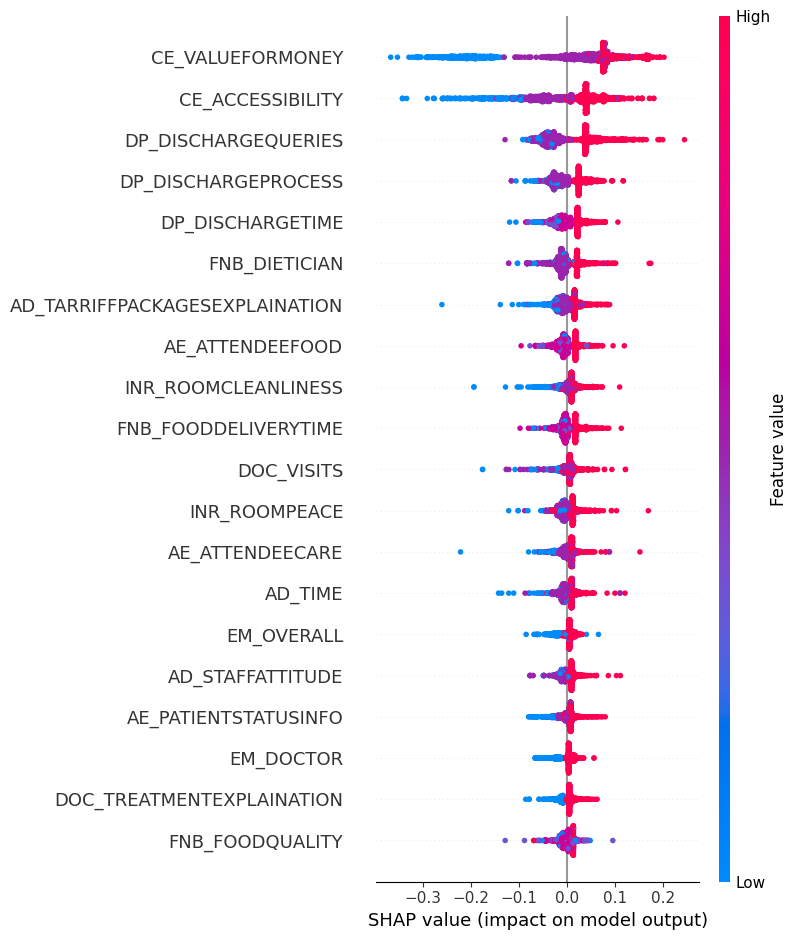

In [ ]:
shap.summary_plot(shap_values_class_1, X_test)


### Importance - Performance Plot

#### Compute the **Importance** (based on SHAP values)

You can compute the **feature importance** by either:

* Use the coef_[0] function for logistic regression

*   Calling up the <a href= https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html>`feature_importances_`</a> function for ensemble models
*   Using the SHAP values like down below



In [ ]:
# To get the importance for each feature, you have to calculate the mean absolute SHAP values for each feature
feature_importance = np.mean(np.abs(shap_values_class_1), axis=0)

# Optionally, sort the features by importance --> np.argsort returns the indices that would sort the feature_importance array in ascending order
sorted_idx = np.argsort(feature_importance)[::-1]   # The slicing with [::-1] reverses the sorted indices, so that the indices now correspond to features sorted in descending order of importance (from most important to least important).
sorted_importance = feature_importance[sorted_idx]
sorted_features = X_test.columns[sorted_idx]

# Display the results
for feature, importance in zip(sorted_features, sorted_importance):
    print(f"{feature}: {importance:.4f}")

CE_VALUEFORMONEY: 0.0974
CE_ACCESSIBILITY: 0.0621
DP_DISCHARGEQUERIES: 0.0453
DP_DISCHARGEPROCESS: 0.0250
DP_DISCHARGETIME: 0.0200
FNB_DIETICIAN: 0.0181
AD_TARRIFFPACKAGESEXPLAINATION: 0.0165
AE_ATTENDEEFOOD: 0.0141
INR_ROOMCLEANLINESS: 0.0138
FNB_FOODDELIVERYTIME: 0.0129
DOC_VISITS: 0.0123
INR_ROOMPEACE: 0.0123
AE_ATTENDEECARE: 0.0113
AD_TIME: 0.0113
EM_OVERALL: 0.0112
AD_STAFFATTITUDE: 0.0110
AE_PATIENTSTATUSINFO: 0.0106
EM_DOCTOR: 0.0102
DOC_TREATMENTEXPLAINATION: 0.0100
FNB_FOODQUALITY: 0.0095
DOC_TREATMENTEFFECTIVENESS: 0.0095
NS_NURSESATTITUDE: 0.0079
NS_CALLBELLRESPONSE: 0.0075
EM_NURSING: 0.0075
OVS_SECURITYATTITUDE: 0.0075
FNB_STAFFATTITUDE: 0.0074
INR_ROOMEQUIPMENT: 0.0070
INR_ROOMAMBIENCE: 0.0069
NS_NURSEPROACTIVENESS: 0.0067
OVS_OVERALLSTAFFPROMPTNESS: 0.0066
NS_NURSEPATIENCE: 0.0064
DOC_ATTITUDE: 0.0053
OVS_OVERALLSTAFFATTITUDE: 0.0050
EM_IMMEDIATEATTENTION: 0.0049


#### Compute the **Performance** (mean of survey answers)

In [ ]:
def performance_calculation(df, features):
    return pd.Series({feature: df[feature].mean() for feature in features}) # For each feature (i.e. survey answer) we calculate the mean performance across all observations

# Compute the performance for each feature in sorted order
performance = performance_calculation(X_train, sorted_features)
sorted_performance = performance.reindex(sorted_features)

# Store both importance and performance in a dataframe
ip = pd.DataFrame({
    "importance": sorted_importance,
    "performance": sorted_performance
}, index=sorted_features)

ip

NameError: name 'sorted_features' is not defined

In [ ]:
# Filter out unwanted features from the ip DataFrame
features_to_remove = ["CE_VALUEFORMONEY", "CE_ACCESSIBILITY"]
ip = ip[~ip.index.isin(features_to_remove)]
print("\nAfter filtering:")
print(ip)


After filtering:
                                importance  performance
DP_DISCHARGEQUERIES               0.045266     3.259401
DP_DISCHARGEPROCESS               0.024968     3.167782
DP_DISCHARGETIME                  0.020047     3.051944
FNB_DIETICIAN                     0.018053     3.127470
AD_TARRIFFPACKAGESEXPLAINATION    0.016536     3.164436
AE_ATTENDEEFOOD                   0.014089     2.989802
INR_ROOMCLEANLINESS               0.013787     3.239324
FNB_FOODDELIVERYTIME              0.012944     3.067400
DOC_VISITS                        0.012312     3.492352
INR_ROOMPEACE                     0.012278     3.211122
AE_ATTENDEECARE                   0.011348     3.289834
AD_TIME                           0.011308     3.231517
EM_OVERALL                        0.011197     3.656150
AD_STAFFATTITUDE                  0.010978     3.365360
AE_PATIENTSTATUSINFO              0.010616     3.320746
EM_DOCTOR                         0.010203     3.747451
DOC_TREATMENTEXPLAINATION     

#### Plot the Importance-Performance

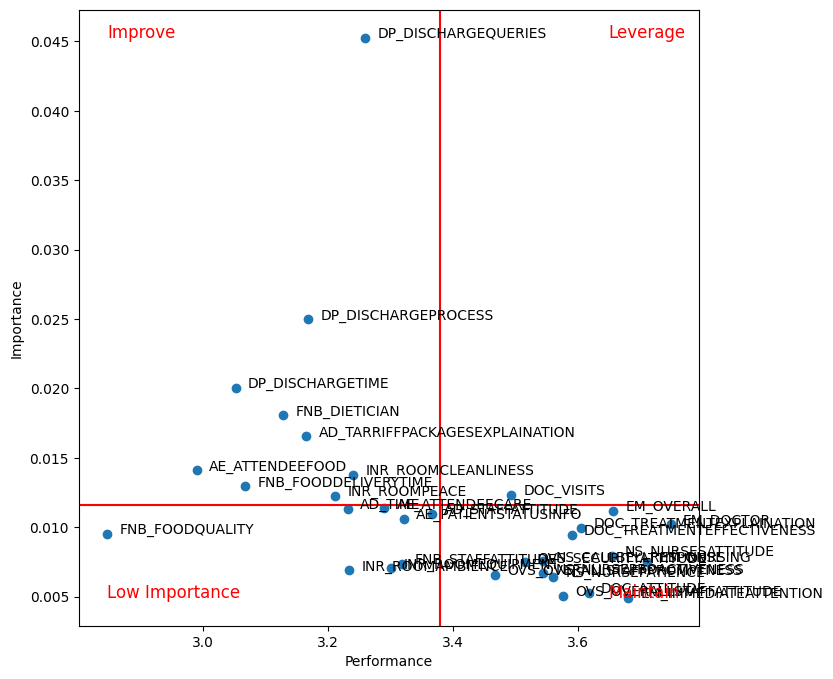

In [ ]:
# Create the importance/performance plot using the filtered ip DataFrame
plt.figure(figsize=(8,8))
plt.xlabel('Performance')
plt.ylabel('Importance')
plt.scatter(ip.performance, ip.importance) # This line prints the blue dots on the graph

# Label each datapoint with its feature name
for i in range(len(ip)):
    plt.annotate(ip.index[i], (ip.performance[i] + 0.02, ip.importance[i]), fontsize=10)

# Draw horizontal and vertical lines at the mean values
plt.axhline(y=ip.importance.mean(), color='r', linestyle='-')
plt.axvline(x=ip.performance.mean(), color='r', linestyle='-')

# Label each quadrant (adjust positioning if necessary)
plt.annotate("Low Importance", (ip.performance.min(), ip.importance.min()), color='r', fontsize=12)
plt.annotate("Improve", (ip.performance.min(), ip.importance.max()), color='r', fontsize=12)
plt.annotate("Leverage", (ip.performance.max() - 0.10, ip.importance.max()), color='r', fontsize=12)
plt.annotate("Maintain", (ip.performance.max() - 0.10, ip.importance.min()), color='r', fontsize=12)

plt.show()

## Clustering

### Clustering based on background

Check which features we will use and what their data type is:

In [ ]:
%%capture
!wget -O hospital_dataset_background.csv 'https://drive.google.com/uc?export=download&id=1AbZ5VT1KQ-tCk6Q5-d9uUTZ1FdLbLqLt'

df = pd.read_csv('hospital_dataset_background.csv')

In [ ]:
df.head() # We take a look at the first 5 rows of the dataset

,SN,MaritalStatus,AgeYrs,Gender,BedCategory,Department,Estimatedcost,CE_ACCESSIBILITY,CE_VALUEFORMONEY,EM_IMMEDIATEATTENTION,...,OVS_OVERALLSTAFFATTITUDE,OVS_OVERALLSTAFFPROMPTNESS,OVS_SECURITYATTITUDE,DP_DISCHARGETIME,DP_DISCHARGEQUERIES,DP_DISCHARGEPROCESS,AdmissionDate,DischargeDate,LengthofStay,Satisfaction
0,1,Single,4.0,F,SPECIAL,PEDIATRIC,25000.0,4,4,4,...,4,4,4,4,4,4,18/07/2014,21/07/2014,3,1
1,2,Single,13.0,F,SPECIAL,PEDIATRIC,15000.0,4,4,4,...,4,4,4,4,4,4,11/07/2014,16/07/2014,5,1
2,3,Married,33.0,F,SEMISPECIAL,GYNAEC,70000.0,3,2,4,...,4,4,4,3,4,3,17/06/2014,20/07/2014,33,1
3,4,Married,51.0,F,SPECIAL,GYNAEC,150000.0,4,3,4,...,4,3,3,3,4,3,16/07/2014,22/07/2014,6,1
4,5,Married,31.0,F,SPECIAL,GYNAEC,100000.0,4,4,4,...,4,4,4,4,4,4,13/07/2014,16/07/2014,3,1


In [ ]:
df_background = df[['MaritalStatus','AgeYrs', 'Gender','BedCategory','Department', 'Estimatedcost']]
df_background.dtypes

,0
MaritalStatus,object
AgeYrs,float64
Gender,object
BedCategory,object
Department,object
Estimatedcost,float64


We will only use the following variables:
- AgeYrs
- Gender
- Department


But feel free to play around and include the other ones too!

In [ ]:
# Create a new dataframe df_clus for the chosen background variables
df_clus = df_background[["Gender", "Department", "AgeYrs"]].copy()
df_clus.head()

,Gender,Department,AgeYrs
0,F,PEDIATRIC,4.0
1,F,PEDIATRIC,13.0
2,F,GYNAEC,33.0
3,F,GYNAEC,51.0
4,F,GYNAEC,31.0


#### Kmeans
<br>

- Clustering on **numerical variables**
- Based on distance between the data points

#### Kmodes
<br>

- Clustering on **categorical variables**
- Based on dissimilarities between the data points

In [ ]:
bins = pd.IntervalIndex.from_tuples([(0, 18), (18, 24), (24, 34), (34, 44),
                                     (44, 54), (54, 64), (64, 100)])
df_clus.AgeYrs = pd.cut(df_clus.AgeYrs, bins)
df_clus.head()

,Gender,Department,AgeYrs
0,F,PEDIATRIC,"(0, 18]"
1,F,PEDIATRIC,"(0, 18]"
2,F,GYNAEC,"(24, 34]"
3,F,GYNAEC,"(44, 54]"
4,F,GYNAEC,"(24, 34]"


#### Find the optimal number of clusters (K)
<br>

- Step 1: Calculate the cost for several values of K
    - Cost is the sum of all the dissimilarities between the clusters
    - Cost goes down as number of clusters increases

In [ ]:
cost = []
K = range(1,10)
for num_clusters in list(K):
    kmode = KModes(n_clusters=num_clusters, verbose=False)
    kmode.fit_predict(df_clus)
    cost.append(kmode.cost_)

- Step 2: Optimal value of K is at the "elbow"
    - Where the decrease in cost becomes smaller

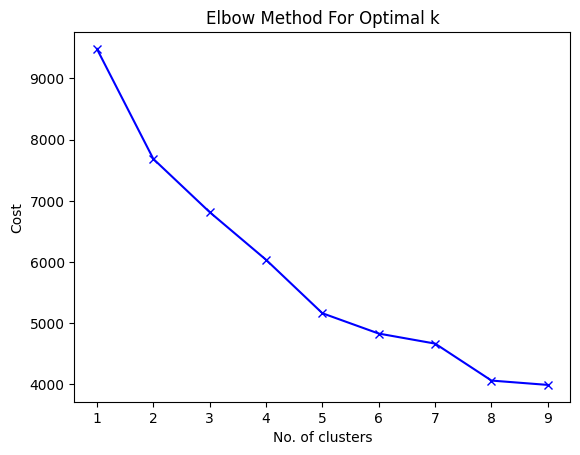

In [ ]:
plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k')
plt.show()

You can visually determine where the "elbow" is or use a package to find it

In [ ]:
kl = KneeLocator(range(1, 10), cost,
            curve="convex",
            direction="decreasing")
kl.elbow

5

#### Build the clusters

In [ ]:
kmode = KModes(n_clusters=kl.elbow, init = "Huang", random_state= 0, verbose=False)
clusters = kmode.fit_predict(df_clus)

In [ ]:
?KModes

How many instances are there in each cluster?

In [ ]:
unique, counts = np.unique(kmode.labels_, return_counts=True)
dict(zip(unique, counts))

{0: 2387, 1: 876, 2: 921, 3: 421, 4: 748}


Let's create a new column to include the cluster labels

In [ ]:
df_clus["Cluster"] = clusters
df_clus.head()

,Gender,Department,AgeYrs,Cluster
0,F,PEDIATRIC,"(0, 18]",4
1,F,PEDIATRIC,"(0, 18]",4
2,F,GYNAEC,"(24, 34]",0
3,F,GYNAEC,"(44, 54]",0
4,F,GYNAEC,"(24, 34]",0


#### What are the characteristics of each cluster?

In [ ]:
df_clus.groupby(['Cluster']).agg(pd.Series.mode)

,Gender,Department,AgeYrs
Cluster,,,
0,F,GEN,"(24, 34]"
1,M,SPECIAL,"(54, 64]"
2,M,GEN,"(34, 44]"
3,M,SPECIAL,"(64, 100]"
4,M,PEDIATRIC,"(0, 18]"


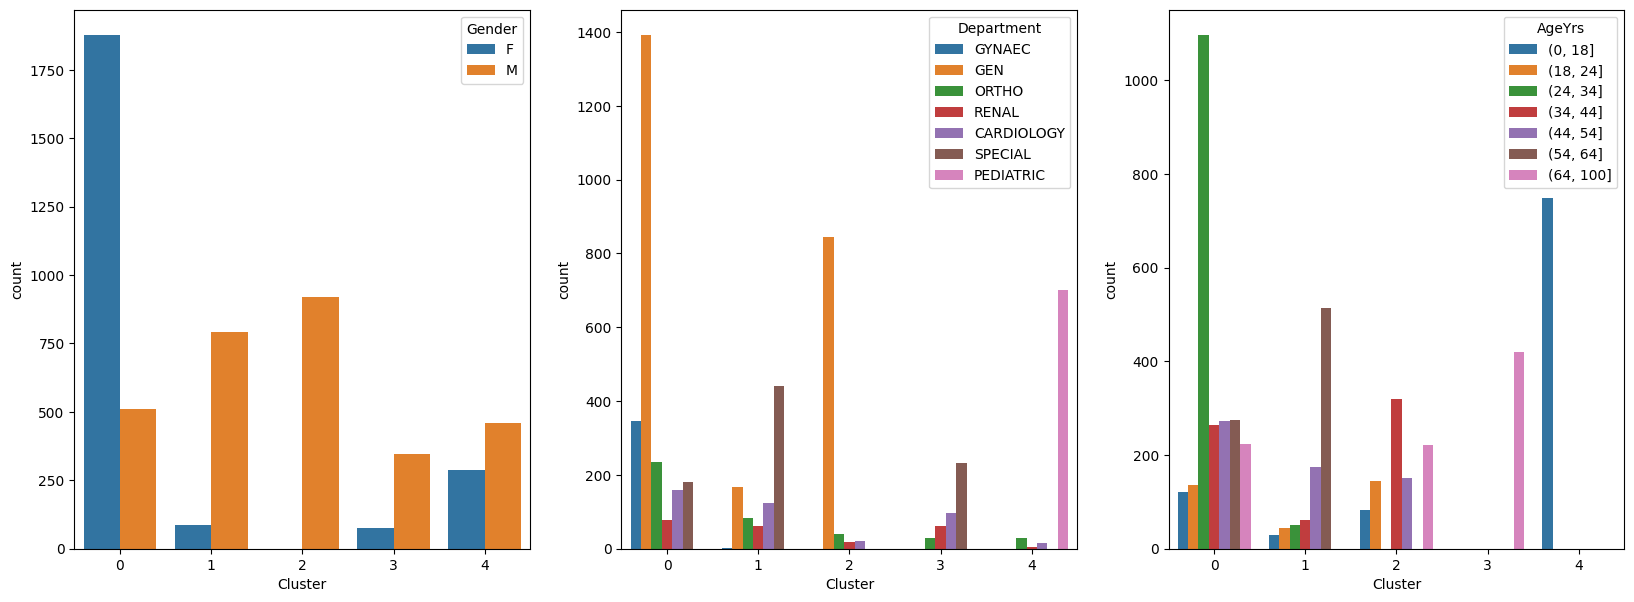

In [ ]:
fig = plt.figure(figsize=(20,7))

for i, col in enumerate(['Gender', 'Department', 'AgeYrs']):
    plt.subplot(1, 3, i+1)
    sns.countplot(x= "Cluster",hue = col, data = df_clus)

### Predictive model per cluster

In [ ]:
columns_to_remove = ['SN', 'MaritalStatus', 'AgeYrs', 'Gender', 'BedCategory',
                     'Department', 'Estimatedcost', 'AdmissionDate',
                     'DischargeDate', 'LengthofStay', 'Satisfaction']
df_survey = df.drop(columns=columns_to_remove)
df_satisfaction = df["Satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(
    df_survey, df_satisfaction, test_size=0.2, random_state=42)

In [ ]:
X_clus = X_train.join(df_clus['Cluster']) # Add the cluster label to each observation
X_clus.head()

,CE_ACCESSIBILITY,CE_VALUEFORMONEY,EM_IMMEDIATEATTENTION,EM_NURSING,EM_DOCTOR,EM_OVERALL,AD_TIME,AD_TARRIFFPACKAGESEXPLAINATION,AD_STAFFATTITUDE,INR_ROOMCLEANLINESS,...,NS_NURSESATTITUDE,NS_NURSEPROACTIVENESS,NS_NURSEPATIENCE,OVS_OVERALLSTAFFATTITUDE,OVS_OVERALLSTAFFPROMPTNESS,OVS_SECURITYATTITUDE,DP_DISCHARGETIME,DP_DISCHARGEQUERIES,DP_DISCHARGEPROCESS,Cluster
2369,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,4,3,1
3955,3,3,3,3,3,3,3,2,3,3,...,3,3,3,3,3,3,2,3,2,0
3785,3,3,4,4,4,4,3,4,4,3,...,4,4,4,4,4,4,3,3,3,4
120,4,4,4,4,4,4,4,4,4,4,...,4,3,4,4,3,4,4,4,4,0
3699,4,4,4,4,4,4,3,3,3,3,...,3,3,3,3,3,3,3,3,3,0


In [ ]:
y_clus = y_train.to_frame()
y_clus= y_clus.join(df_clus['Cluster'])
y_clus.head()

,Satisfaction,Cluster
2369,1,1
3955,0,0
3785,1,4
120,1,0
3699,1,0


#### Exercise

Build an Importance-Performance plot for one cluster.

We first make a subset for X_train and y_train that only contains instances belonging to the first cluster and we drop the `cluster`column:

In [ ]:
X_clus_0 = X_clus.loc[X_clus["Cluster"] == 0].drop(['Cluster'], axis=1)
y_clus_0 = y_clus.loc[y_clus["Cluster"] == 0].drop(['Cluster'], axis=1)

1. Fit a Random Forest.

2. Calculate the feature importances

3. Calculate the performance using `performance_calculation` function.

4. Join the importance and performance into a dataframe

5. Plot the importance and performance. To annotate the plot, take a look at the previous importance-performance plot.


#### Solution


1. Fit a Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_clus_0, y_clus_0.values.ravel())

RandomForestClassifier(random_state=42)

2. Calculate the feature importances

In [ ]:
importance = rf.feature_importances_
importance_series = pd.Series(importance, index=X_clus_0.columns)

3. Calculate the performance using performance_calculation function

In [ ]:
def performance_calculation(df, features):
    return pd.Series({feature: df[feature].mean() for feature in features})

performance_series = performance_calculation(X_clus_0, X_clus_0.columns)

4. Join the importance and performance into a dataframe

In [ ]:
# Combine importance and performance into one DataFrame
ip = pd.DataFrame({
    "importance": importance_series,
    "performance": performance_series
})

# Filter out unwanted features from the ip DataFrame
features_to_remove = ["CE_VALUEFORMONEY", "CE_ACCESSIBILITY"]
ip = ip[~ip.index.isin(features_to_remove)]
print("\nAfter filtering:")

ip


After filtering:


,importance,performance
EM_IMMEDIATEATTENTION,0.017871,3.815126
EM_NURSING,0.022532,3.840336
EM_DOCTOR,0.016414,3.858718
EM_OVERALL,0.027883,3.800945
AD_TIME,0.027768,3.377626
AD_TARRIFFPACKAGESEXPLAINATION,0.030347,3.331408
AD_STAFFATTITUDE,0.028123,3.521534
INR_ROOMCLEANLINESS,0.035551,3.411765
INR_ROOMPEACE,0.027083,3.380777
INR_ROOMEQUIPMENT,0.021745,3.459034


5. Create the importance-performance plot for that cluster

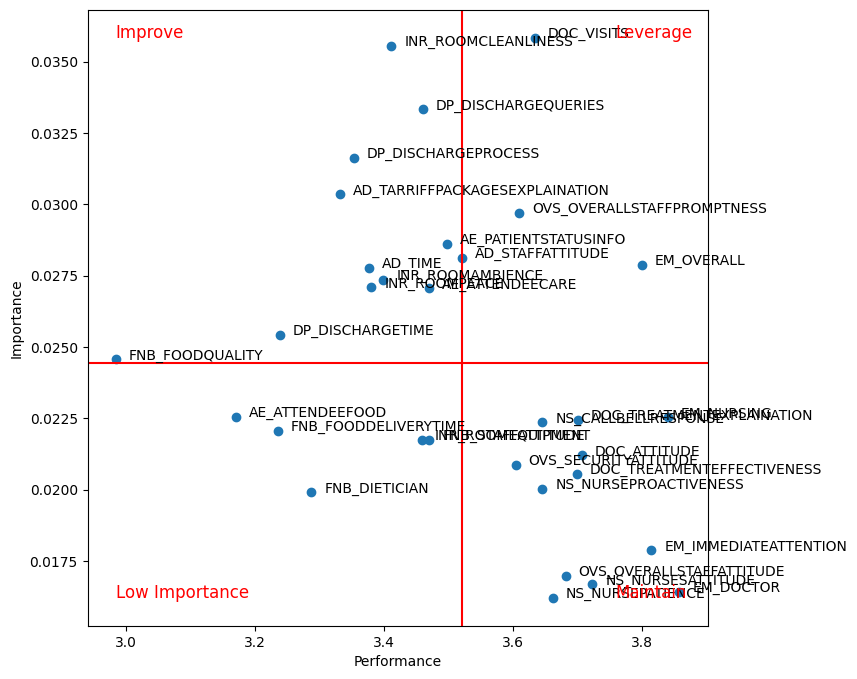

In [ ]:
# Create the importance/performance plot using the filtered ip DataFrame
plt.figure(figsize=(8,8))
plt.xlabel('Performance')
plt.ylabel('Importance')
plt.scatter(ip.performance, ip.importance)

# Label each datapoint with its feature name
for i in range(len(ip)):
    plt.annotate(ip.index[i], (ip.performance[i] + 0.02, ip.importance[i]), fontsize=10)

# Draw horizontal and vertical lines at the mean values
plt.axhline(y=ip.importance.mean(), color='r', linestyle='-')
plt.axvline(x=ip.performance.mean(), color='r', linestyle='-')

# Label each quadrant (adjust positioning if necessary)
plt.annotate("Low Importance", (ip.performance.min(), ip.importance.min()), color='r', fontsize=12)
plt.annotate("Improve", (ip.performance.min(), ip.importance.max()), color='r', fontsize=12)
plt.annotate("Leverage", (ip.performance.max() - 0.10, ip.importance.max()), color='r', fontsize=12)
plt.annotate("Maintain", (ip.performance.max() - 0.10, ip.importance.min()), color='r', fontsize=12)


plt.show()

### Full definition

In [ ]:
def importance_performance(X, y, clf, cluster):

    # 1. Subset cluster
    X_clus = X.loc[X["Cluster"] == cluster].drop(['Cluster'], axis=1)
    y_clus = y.loc[y["Cluster"] == cluster].drop(['Cluster'], axis=1)

    # 1. Fit classifier
    clf.fit(X_clus, y_clus.values.ravel())

    # 2. Calculate importance
    try:
        importance = pd.Series(clf.feature_importances_, index = X_clus.columns)
    except AttributeError:# error is going to be raised for logistic regression
        importance = pd.Series(abs(clf.coef_[0]), index = X_clus.columns)

    # 3. Calculate performance
    performance = performance_calculation(X_clus, X_clus.columns)

    # 4. Join importance and performance
    # Combine importance and performance into one DataFrame
    ip = pd.DataFrame({
        "importance": importance,
        "performance": performance
    })

    # Filter out unwanted features from the ip DataFrame
    features_to_remove = ["CE_VALUEFORMONEY", "CE_ACCESSIBILITY"]
    ip = ip[~ip.index.isin(features_to_remove)]

    # 5. Plot
    fig = plt.figure()
    plt.xlabel('Performance')
    plt.ylabel('Importance')
    plt.scatter(ip.performance, ip.importance)

    for i in range(len(ip)):
      plt.annotate(ip.index[i], (ip.performance[i] + 0.02, ip.importance[i]), fontsize=10)

    plt.axhline(y= ip.importance.mean(), color='r', linestyle='-')
    plt.axvline(x= ip.performance.mean(), color='r', linestyle='-')

    # Label each quadrant (adjust positioning if necessary)
    plt.annotate("Low Importance", (ip.performance.min(), ip.importance.min()), color='r', fontsize=12)
    plt.annotate("Improve", (ip.performance.min(), ip.importance.max()), color='r', fontsize=12)
    plt.annotate("Leverage", (ip.performance.max() - 0.10, ip.importance.max()), color='r', fontsize=12)
    plt.annotate("Maintain", (ip.performance.max() - 0.10, ip.importance.min()), color='r', fontsize=12)


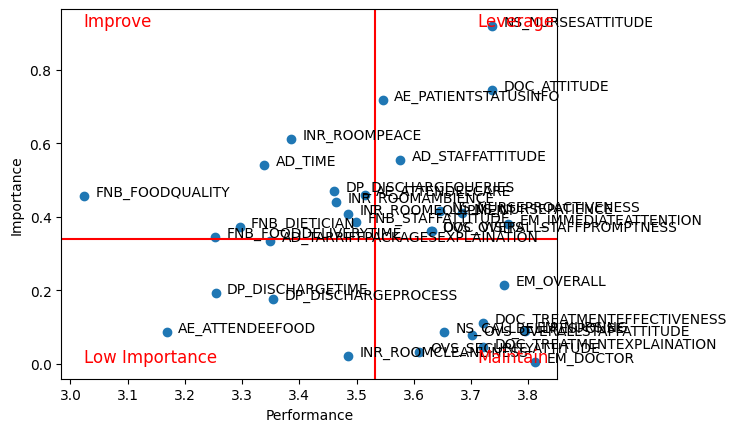

In [ ]:
importance_performance(X_clus, y_clus, LogisticRegression(), 4)


### Important Features per Patient

<video
       src="https://www.dropbox.com/scl/fi/93xwlgtzhakyqv41nfqjj/dashboard_hospitalcase.mp4?rlkey=nozwjc3jlnt5l4xqdn647p8zb&raw=1"  
       controls width=100%>  
</video>
